### Step 1: Mount the Google Drive

Remember to use GPU runtime before mounting your Google Drive. (Runtime --> Change runtime type).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 2: Open the project directory

Replace `Your_Dir` with your own path.

In [3]:
cd /content/drive/MyDrive/Colab Notebooks/c247a_final3/emg2qwerty_W26

/content/drive/MyDrive/Colab Notebooks/c247a_final3/emg2qwerty_W26


In [4]:
import os

dataset_dir = './data/'
if os.path.exists(dataset_dir):
    print(f"The directory '{dataset_dir}' exists.")
else:
    print(f"The directory '{dataset_dir}' does NOT exist. Please create it and place your dataset files there.")

The directory './data/' exists.


### Step 3: Install required packages

After installing them, Colab will require you to restart the session.

In [5]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.6/553.6 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of typer to determine which version is

### Step 4: Start your experiments!

- Remember to download and copy the dataset to this directory: `Your_Dir/emg2qwerty/data`.
- You may now start your experiments with any scripts! Below are examples of single-user training and testing (greedy decoding).
- **There are two ways to track the logs:**
  - 1. Keep `--multirun`, and the logs will not be printed here, but they will be saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/submitit_logs/`.
  - 2. Comment out `--multirun` and the logs will be printed in this notebook, but they will not be saved.

#### Training

- The checkpoints are saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/checkpoints/`.

In [ ]:
# Single-user training
!python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu trainer.devices=1 \
  --multirun

# !python -m emg2qwerty.train \
#   user="single_user" \
#   "checkpoint='/content/drive/MyDrive/Colab Notebooks/c247a_final/emg2qwerty_W26/logs/default-hybrid-CNN-RNN/Training/job0_trainer.devices=1,user=single_user/checkpoints/epoch=29-step=3600.ckpt'" \
#   trainer.accelerator=gpu trainer.devices=1 \
#   --multirun

[2026-03-09 01:52:54,847][HYDRA] Launching 1 jobs locally
[2026-03-09 01:52:54,847][HYDRA] 	#0 : user=single_user trainer.accelerator=gpu trainer.devices=1
[2026-03-09 01:52:55,065][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-st

Global seed set to 1501
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: d:\ECE 247\emg2qwerty_W26\logs\2026-03-09\01-52-54\job0_trainer.devices=1,user=single_user\lightning_logs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\ECE 247\emg2qwerty_W26\.venv\Lib\site-packages\pl_bolts\__init__.py:11: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, tp_name):
d:\ECE 247\emg2qwerty_W26\.venv\Lib\site-packages\pl_bolts\__init__.py:11: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, tp_name):
d:\ECE 247\emg2qwerty_W26\.venv\Lib\site-packages\pl_bolts\models\self_supervised\amdim\amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guara

In [ ]:
# # Single-user testing
# !python -m emg2qwerty.train \
#   user="single_user" \
#   "checkpoint='/content/drive/MyDrive/Colab Notebooks/c247a_final/emg2qwerty_W26/logs/default-hybrid-CNN-Transformer/Training2/job0_trainer.devices=1,user=single_user/checkpoints/epoch=28-step=3480.ckpt'" \
#   train=False\
#   trainer.accelerator=gpu \
#   decoder=ctc_greedy \
#   # hydra.launcher.mem_gb=64 \
#   --multirun

!python -m emg2qwerty.train \
  user="single_user" \
  "checkpoint='./logs/default-hybrid-CNN-LSTM/Training_multi/job0_trainer.devices=1,user=multi_user/checkpoints/epoch=27-step=7896.ckpt'" \
  train=False\
  trainer.accelerator=gpu \
  decoder=ctc_greedy \
  --multirun

[2026-03-09 01:24:22,258][HYDRA] Launching 1 jobs locally
[2026-03-09 01:24:22,258][HYDRA] 	#0 : user=single_user checkpoint='./logs/default-hybrid-CNN-LSTM/Training_multi/job0_trainer.devices=1,user=multi_user/checkpoints/epoch=27-step=7896.ckpt' train=False trainer.accelerator=gpu decoder=ctc_greedy
[2026-03-09 01:24:22,425][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-0

Global seed set to 1501
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: d:\ECE 247\emg2qwerty_W26\logs\2026-03-09\01-24-22\job0_decoder=ctc_greedy,train=False,user=single_user\lightning_logs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


# Task
plot the validation CER against the epoch number



Plot the validation CER against the epoch number for each model (TDSConvEncoder, LSTMEncoder, and GRUEncoder) on a single plot, using different colored lines for each model and including a legend, title, and axis labels.

In [ ]:

import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os

# log_dir_LSTM = './logs/default-LSTMEncoder/Training/job0_trainer.devices=1,user=single_user/lightning_logs/version_0/'
# log_dir_GRU = './logs/default-GRUEncoder/Training/job0_trainer.devices=1,user=single_user/lightning_logs/version_0/'
# log_dir_TDSConv = './logs/default-TDSConvEncoder/Training/job0_trainer.devices=1,user=single_user/lightning_logs/version_0/'
# log_dir_Transformer ='./logs/default-Transformer/Training/job0_trainer.devices=1,user=single_user/lightning_logs/version_0/'
log_dir_hybrid_CNN_LSTM = './logs/default-hybrid-CNN-LSTM/Training/job0_trainer.devices=1,user=single_user/lightning_logs/version_0/'
# log_dir_hybrid_CNN_LSTM_MULTI = './logs/default-hybrid-CNN-LSTM/Training_multi/job0_trainer.devices=1,user=multi_user/lightning_logs/version_0/'
log_dir_hybrid_CNN_LSTM_MULTI = './logs/default-hybrid-CNN-LSTM/Training_multi/job0_trainer.devices=1,user=multi_user/lightning_logs/version_0/'
# log_dir_hybrid_CNN_GRU = './logs/default-hybrid-CNN-GRU/Training/job0_trainer.devices=1,user=single_user/lightning_logs/version_0/'
# log_dir_hybrid_CNN_Transformer = './logs/default-hybrid-CNN-Transformer/Training/job0_trainer.devices=1,user=single_user/lightning_logs/version_0/'
# log_dir_hybrid_CNN_RNN = './logs/default-hybrid-CNN-RNN/Training/job0_trainer.devices=1,user=single_user/lightning_logs/version_0/'

log_dirs_and_names = [
    # (log_dir_TDSConv, 'TDSConvEncoder'),
    # (log_dir_LSTM, 'LSTMEncoder'),
    # (log_dir_GRU, 'GRUEncoder'),
    (log_dir_hybrid_CNN_LSTM, 'hybrid-CNN-LSTM'),
    (log_dir_hybrid_CNN_LSTM_MULTI, 'hybrid-CNN-LSTM-MULTI'),
    # (log_dir_hybrid_CNN_GRU, 'hybrid-CNN-GRU'),
    # (log_dir_hybrid_CNN_Transformer, 'hybrid-CNN-Transformer'),
    # (log_dir_hybrid_CNN_RNN, 'hybrid-CNN-RNN')
]

df_metrics_all = []

for log_dir, model_name in log_dirs_and_names:
    print(f"Processing logs for model: {model_name}")

    event_files = [
        os.path.join(log_dir, f)
        for f in os.listdir(log_dir)
        if 'events.out.tfevents' in f
    ]

    epoches = []
    val_cers = []

    for event_file in event_files:
        event_acc = EventAccumulator(event_file)
        event_acc.Reload()

        if 'val/CER' in event_acc.Tags()['scalars'] and 'epoch' in event_acc.Tags()['scalars']:
            val_cer_events = event_acc.Scalars('val/CER')
            epoch_events = event_acc.Scalars('epoch')

            epoch_map = {e.step: int(e.value) for e in epoch_events}

            for event in val_cer_events:
                if event.step in epoch_map:
                    epoches.append(epoch_map[event.step])
                    val_cers.append(event.value)

    df_metrics = pd.DataFrame({
        'epoch': epoches,
        'val/CER': val_cers
    })

    df_metrics = df_metrics.drop_duplicates(subset=['epoch'], keep='last')
    df_metrics = df_metrics.sort_values(by='epoch').reset_index(drop=True)
    df_metrics['model_name'] = model_name

    df_metrics_all.append(df_metrics)

df_combined_metrics = pd.concat(df_metrics_all, ignore_index=True)

print("\nCombined Metrics DataFrame Head:")
print(df_combined_metrics.head())

# Get best validation CER per model
best_per_model = (
    df_combined_metrics.loc[
        df_combined_metrics.groupby('model_name')['val/CER'].idxmin()
    ]
    .sort_values('val/CER')
    .reset_index(drop=True)
)

print("\nBest validation CER per model:")
print(best_per_model[['model_name', 'epoch', 'val/CER']].to_string(index=False))

# Get overall best model
overall_best = best_per_model.iloc[0]
print("\nOverall best validation result:")
print(f"Model: {overall_best['model_name']}")
print(f"Epoch: {overall_best['epoch']}")
print(f"Best val/CER: {overall_best['val/CER']:.4f}")

Processing logs for model: hybrid-CNN-LSTM
Processing logs for model: hybrid-CNN-LSTM-MULTI

Combined Metrics DataFrame Head:
   epoch     val/CER       model_name
0      0  1318.01062  hybrid-CNN-LSTM
1      1   100.00000  hybrid-CNN-LSTM
2      2   100.00000  hybrid-CNN-LSTM
3      3   100.00000  hybrid-CNN-LSTM
4      4   100.00000  hybrid-CNN-LSTM

Best validation CER per model:
           model_name  epoch   val/CER
      hybrid-CNN-LSTM     28 19.162605
hybrid-CNN-LSTM-MULTI     27 22.492666

Overall best validation result:
Model: hybrid-CNN-LSTM
Epoch: 28
Best val/CER: 19.1626


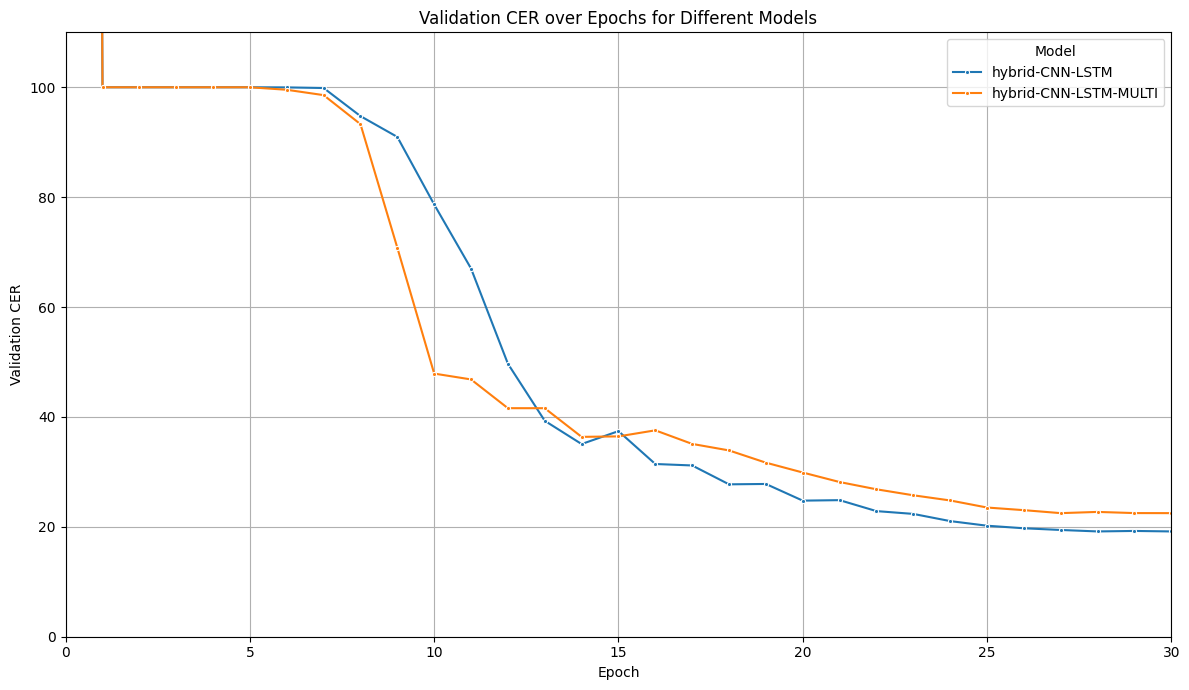

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.lineplot(data=df_combined_metrics, x='epoch', y='val/CER', hue='model_name', marker='.')

plt.title('Validation CER over Epochs for Different Models')
plt.xlabel('Epoch')
plt.ylabel('Validation CER')
plt.grid(True)
plt.xticks(df_combined_metrics['epoch'].unique()[::5]) # Adjust x-axis ticks for readability
plt.legend(title='Model')
plt.xlim([0,30])
plt.ylim([0,110])
plt.tight_layout()
plt.show()

## Extract Test CER for All Models

### Subtask:
Extract the final 'test/CER' metric for each of the 7 models from their respective log directories and store them in a list of dictionaries.


In [14]:
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os

# log_dir_LSTM = './logs/default-LSTMEncoder/Testing/lightning_logs/version_0'
# log_dir_GRU = './logs/default-GRUEncoder/Testing/lightning_logs/version_0'
# log_dir_TDSConv = './logs/default-TDSConvEncoder/Testing/lightning_logs/version_0'
# log_dir_Transformer ='./logs/default-Transformer/Testing/lightning_logs/version_0'
# log_dir_hybrid_CNN_LSTM = './logs/default-hybrid-CNN-LSTM/Testing/lightning_logs/version_0'
# log_dir_hybrid_CNN_LSTM_MULTI = './logs/default-hybrid-CNN-LSTM/Testing_multi_on_single_data/lightning_logs/version_0'
# log_dir_hybrid_CNN_GRU = './logs/default-hybrid-CNN-GRU/Testing/lightning_logs/version_0'
# log_dir_hybrid_CNN_RNN = './logs/default-hybrid-CNN-RNN/Testing/lightning_logs/version_0'
# log_dir_hybrid_CNN_Transformer = './logs/default-hybrid-CNN-Transformer/Testing2/lightning_logs/version_0'


log_dir_hybrid_CNN_LSTM_hoplength12 ='./logs/hybridcnnlastm_hoplength12/Testing/lightning_logs/version_0'
log_dir_hybrid_CNN_LSTM_hoplength20 ='./logs/hybridcnnlastm_hoplength20/Testing/lightning_logs/version_0'
log_dir_hybrid_CNN_LSTM_maxoffset60 ='./logs/hybridcnnlastm_maxoffset60/Testing/lightning_logs/version_0'
log_dir_hybrid_CNN_LSTM_maxoffset180 ='./logs/hybridcnnlastm_maxoffset180/Testing/lightning_logs/version_0'
log_dir_hybrid_CNN_LSTM_10001 ='./logs/hybridcnnlastm_offset-10001/Testing/lightning_logs/version_0'
log_dir_hybrid_CNN_LSTM_21012 ='./logs/hybridcnnlastm_offset-2-1012/Testing/lightning_logs/version_0'
log_dir_hybrid_CNN_LSTM_samplingrate1000hz ='./logs/hybridcnnlastm_samplingrate1000hz/Testing/lightning_logs/version_0'
log_dir_hybrid_CNN_LSTM_samplingrate1250hz ='./logs/hybridcnnlastm_samplingrate1250hz/Testing/lightning_logs/version_0'
log_dir_hybrid_CNN_LSTM_samplingrate1500hz ='./logs/hybridcnnlastm_samplingrate1500hz/Testing/lightning_logs/version_0'
log_dir_hybrid_CNN_LSTM_samplingrate750hz ='./logs/hybridcnnlastm_samplingrate750hz/Testing/lightning_logs/version_0'
log_dir_hybrid_CNN_LSTM_samplingrate1750hz ='./logs/hybridcnnlastm_samplingrate1750hz/Testing/lightning_logs/version_0'
log_dir_hybrid_CNN_LSTM_specaug_n_time_mask1 ='./logs/hybridcnnlastm_specaug_n_time_mask1/Testing/lightning_logs/version_0'
log_dir_hybrid_CNN_LSTM_specaug_n_time_mask6 ='./logs/hybridcnnlastm_specaug_n_time_mask6/Testing/lightning_logs/version_0'
log_dir_hybrid_CNN_LSTM_default ='./logs/hybridcnnlastm_default/Testing/lightning_logs/version_0'

# Create a list of tuples: (log_directory, model_name)
log_dirs_and_names = [
    # (log_dir_TDSConv, 'TDSConvEncoder'),
    # (log_dir_LSTM, 'LSTMEncoder'),
    # (log_dir_GRU, 'GRUEncoder'),
    # (log_dir_Transformer,'TransformerEncoder'),
    # (log_dir_hybrid_CNN_LSTM,'hybrid-CNN-LSTM'),
    # (log_dir_hybrid_CNN_LSTM_MULTI, 'hybrid-CNN-LSTM-Multi-User-data'),
    # (log_dir_hybrid_CNN_GRU,'hybrid-CNN-GRU'),
    # (log_dir_hybrid_CNN_RNN,'hybrid-CNN-RNN'),
    # (log_dir_hybrid_CNN_Transformer,'hybrid-CNN-Transformer'),
    # (log_dir_hybrid_CNN_LSTM_hoplength12,'hoplength12'),
    # (log_dir_hybrid_CNN_LSTM_hoplength20,'hoplength20'),
    # (log_dir_hybrid_CNN_LSTM_maxoffset60,'maxoffset60'),
    # (log_dir_hybrid_CNN_LSTM_maxoffset180,'maxoffset180'),
    # (log_dir_hybrid_CNN_LSTM_10001,'-1,0,0,0,1'),
    # (log_dir_hybrid_CNN_LSTM_21012,'-2,-1,0,1,2'),
    (log_dir_hybrid_CNN_LSTM_samplingrate750hz,'750Hz'),
    (log_dir_hybrid_CNN_LSTM_samplingrate1000hz,'1000Hz'),
    (log_dir_hybrid_CNN_LSTM_samplingrate1250hz,'1250Hz'),
    (log_dir_hybrid_CNN_LSTM_samplingrate1500hz,'1500Hz'),
    (log_dir_hybrid_CNN_LSTM_samplingrate1750hz,'1750Hz'),
    (log_dir_hybrid_CNN_LSTM_default,'2000Hz'),
    # (log_dir_hybrid_CNN_LSTM_specaug_n_time_mask1,'mask1'),
    # (log_dir_hybrid_CNN_LSTM_specaug_n_time_mask6,'mask6'),
]


df_metrics_all = [] # Initialize as an empty list to collect all DataFrames

for log_dir, model_name in log_dirs_and_names:
  print(f"Processing logs for model: {model_name}")

  # List all event files in the directory
  event_files = [os.path.join(log_dir, f) for f in os.listdir(log_dir) if 'events.out.tfevents' in f]

  # Initialize lists to store data for the current model
  epoches = []
  test_cers = []

  # Process each event file
  for event_file in event_files:
      event_acc = EventAccumulator(event_file)
      event_acc.Reload()

      # Check if 'test/CER' and 'epoch' tags exist
      if 'test/CER' in event_acc.Tags()['scalars'] and 'epoch' in event_acc.Tags()['scalars']:
          # Get validation CER events
          test_cer_events = event_acc.Scalars('test/CER')
          # Get epoch events
          epoch_events = event_acc.Scalars('epoch')

          # Create a dictionary for quick lookup of epoch by step
          epoch_map = {e.step: int(e.value) for e in epoch_events}

          # Extract CER and corresponding epoch
          for event in test_cer_events:
              if event.step in epoch_map:
                  epoches.append(epoch_map[event.step])
                  test_cers.append(event.value)

  # Create a DataFrame for the current model
  df_metrics = pd.DataFrame({
      'epoch': epoches,
      'test/CER': test_cers
  })

  # Drop duplicate epoch entries, keeping the last one
  df_metrics = df_metrics.drop_duplicates(subset=['epoch'], keep='last')

  # Sort by epoch
  df_metrics = df_metrics.sort_values(by='epoch').reset_index(drop=True)

  # Add a 'model_name' column to identify the data source
  df_metrics['model_name'] = model_name

  # Append the DataFrame for the current model to the list
  df_metrics_all.append(df_metrics)

print("\nAll metrics collected in df_metrics_all list.")
# Example of how to access them (e.g., the first DataFrame in the list)
# print(df_metrics_all[0].head())

df_combined_metrics = pd.concat(df_metrics_all, ignore_index=True)
print("Combined Metrics DataFrame Head:")
print(df_combined_metrics.to_string())

Processing logs for model: 750Hz
Processing logs for model: 1000Hz
Processing logs for model: 1250Hz
Processing logs for model: 1500Hz
Processing logs for model: 1750Hz
Processing logs for model: 2000Hz

All metrics collected in df_metrics_all list.
Combined Metrics DataFrame Head:
   epoch   test/CER model_name
0      0  35.919601      750Hz
1      0  23.492544     1000Hz
2      0  21.201643     1250Hz
3      0  19.753620     1500Hz
4      0  21.741949     1750Hz
5      0  20.510050     2000Hz


/tmp/ipykernel_7773/3240919206.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_combined_metrics, x='model_name', y='test/CER', palette='viridis')


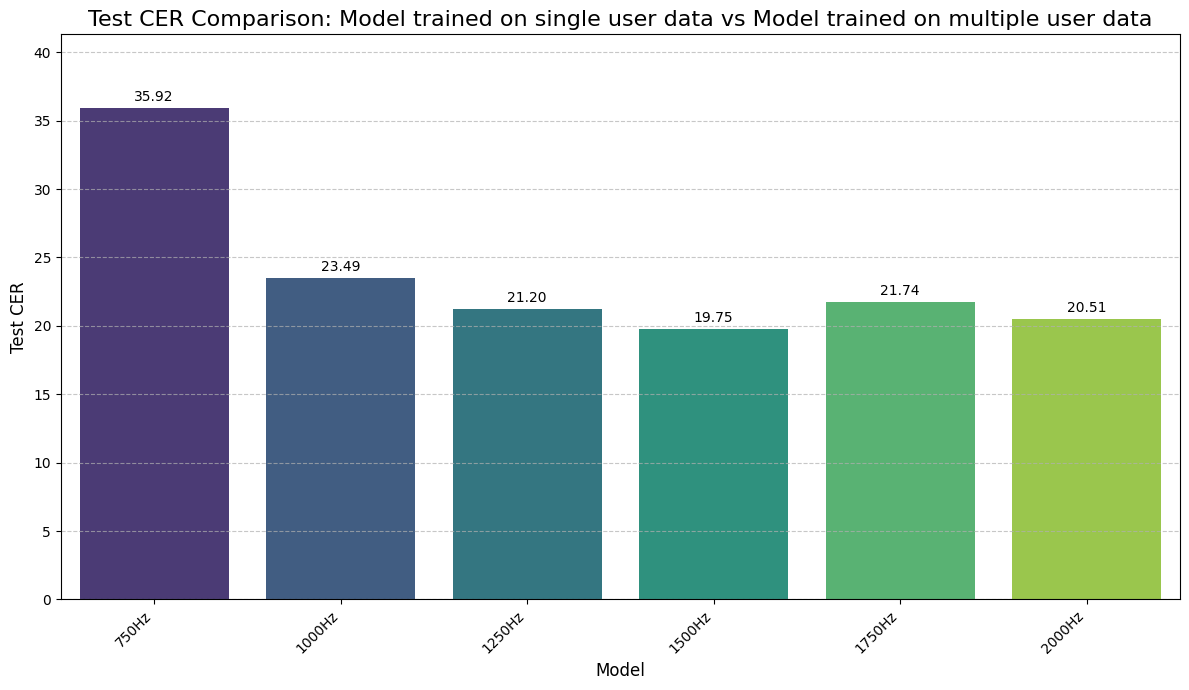

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_combined_metrics, x='model_name', y='test/CER', palette='viridis')

plt.title('Test CER Comparison: Model trained on single user data vs Model trained on multiple user data', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Test CER', fontsize=12)

# Add 'test/CER' values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10, padding=3)

# Adjust y-axis limit to accommodate text labels
max_cer = df_combined_metrics['test/CER'].max()
plt.ylim(0, max_cer * 1.15) # Add 15% buffer above the max value

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()